# Credit card Fraud Detector

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.models import Sequential

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE


In [23]:
import kagglehub
path = kagglehub.dataset_download("quant101/cc-fraud-dataset")
file_path = path + "/creditcard.csv"

Using Colab cache for faster access to the 'cc-fraud-dataset' dataset.


In [24]:
import os

os.listdir(path)

['creditcard.csv']

In [25]:
data = pd.read_csv(file_path)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [31]:
data.shape

(284807, 31)

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [29]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [32]:
data.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [33]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [36]:
data.duplicated().sum()

np.int64(1081)

In [40]:
data = data.drop_duplicates().reset_index(drop=True)

In [41]:
data.duplicated().sum()

np.int64(0)

In [45]:
data["Class"].value_counts()

,count
Class,
0,283253
1,473


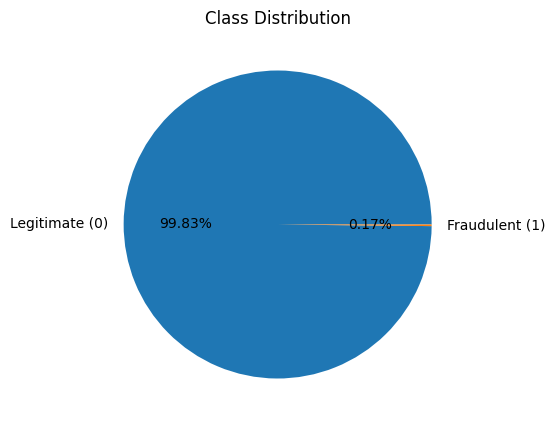

In [47]:
class_counts = data["Class"].value_counts()

plt.figure(figsize=(7, 5))

plt.pie(
    class_counts,
    labels=["Legitimate (0)", "Fraudulent (1)"],
    autopct="%1.2f%%"
)

plt.title("Class Distribution")

plt.show()

In [52]:
X = data.drop("Class", axis=1)
y = data["Class"]

In [53]:
y.shape

(283726,)

In [54]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [55]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [58]:
X_train.shape, X_val.shape, X_test.shape

((198608, 30), (42559, 30), (42559, 30))

In [59]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [60]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
print(class_weights)

Class weights:
{np.int64(0): np.float64(0.5008346908617742), np.int64(1): np.float64(300.012084592145)}


In [61]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [62]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    198277
1       331
Name: count, dtype: int64

After SMOTE:
Class
0    198277
1    198277
Name: count, dtype: int64


In [66]:
def build_model_1(input_dim):

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),

        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model

In [67]:
model_1 = build_model_1(X_train_scaled.shape[1])

In [68]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    patience=10,
    mode="max",
    restore_best_weights=True
)

In [76]:
history_1 = model_1.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=50,
    batch_size=1024,

    class_weight=class_weights,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9949 - auc: 0.9997 - loss: 0.0112 - pr_auc: 0.7913 - precision: 0.2474 - recall: 1.0000 - val_accuracy: 0.9959 - val_auc: 0.9418 - val_loss: 0.0143 - val_pr_auc: 0.6818 - val_precision: 0.2691 - val_recall: 0.8451
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9973 - auc: 0.9998 - loss: 0.0057 - pr_auc: 0.8360 - precision: 0.3809 - recall: 1.0000 - val_accuracy: 0.9978 - val_auc: 0.9425 - val_loss: 0.0101 - val_pr_auc: 0.6897 - val_precision: 0.4203 - val_recall: 0.8169
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9979 - auc: 0.9999 - loss: 0.0048 - pr_auc: 0.8775 - precision: 0.4449 - recall: 1.0000 - val_accuracy: 0.9970 - val_auc: 0.9422 - val_loss: 0.0121 - val_pr_auc: 0.6804 - val_precision: 0.3333 - val_recall: 0.8169
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9983 - auc: 0.9999 - loss: 0.0036 - pr_auc: 0.9106 - precision: 0.4977 - recall: 1.0000 - va

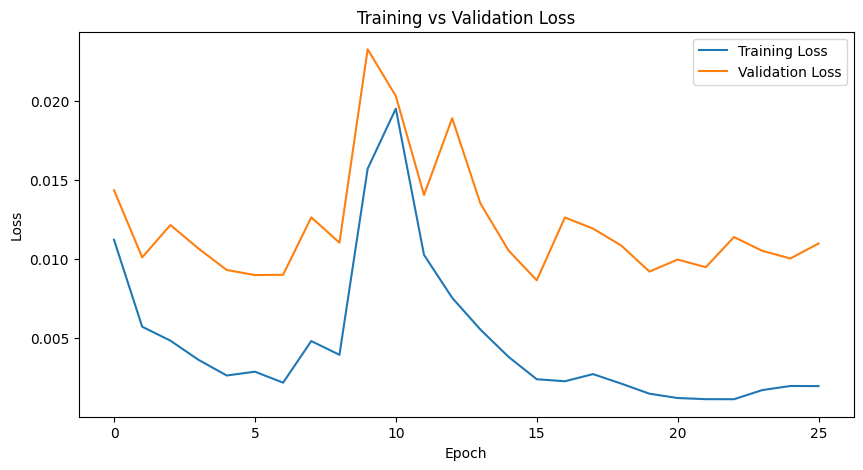

In [77]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_1.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_1.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [78]:
def build_model_2(input_dim):

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),

        layers.Dense(64, activation="tanh"),
        layers.Dropout(0.30),

        layers.Dense(32, activation="tanh"),
        layers.Dropout(0.20),

        layers.Dense(16, activation="tanh"),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=0.01,
            momentum=0.9
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model

In [79]:
model_2 = build_model_2(X_train_scaled.shape[1])

history_2 = model_2.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=50,
    batch_size=1024,

    class_weight=class_weights,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9017 - auc: 0.9629 - loss: 0.2412 - pr_auc: 0.3492 - precision: 0.0152 - recall: 0.9063 - val_accuracy: 0.9386 - val_auc: 0.9708 - val_loss: 0.1520 - val_pr_auc: 0.7135 - val_precision: 0.0236 - val_recall: 0.8873
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9460 - auc: 0.9828 - loss: 0.1630 - pr_auc: 0.6625 - precision: 0.0278 - recall: 0.9245 - val_accuracy: 0.9442 - val_auc: 0.9796 - val_loss: 0.1397 - val_pr_auc: 0.7474 - val_precision: 0.0275 - val_recall: 0.9437
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9534 - auc: 0.9848 - loss: 0.1485 - pr_auc: 0.6638 - precision: 0.0328 - recall: 0.9456 - val_accuracy: 0.9554 - val_auc: 0.9803 - val_loss: 0.1116 - val_pr_auc: 0.7064 - val_precision: 0.0332 - val_recall: 0.9155
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9507 - auc: 0.9865 - loss: 0.1471 - pr_auc: 0.6894 - precision: 0.0306 - recall: 0.9305 - v

In [80]:
def build_model_3(input_dim):

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.25),

        layers.Dense(32, activation="relu"),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model

In [81]:
model_3 = build_model_3(X_train_scaled.shape[1])

history_3 = model_3.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=100,
    batch_size=1024,

    class_weight=class_weights,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9886 - auc: 0.9129 - loss: 0.3528 - pr_auc: 0.6007 - precision: 0.1056 - recall: 0.7855 - val_accuracy: 0.9808 - val_auc: 0.9531 - val_loss: 0.0978 - val_pr_auc: 0.7174 - val_precision: 0.0712 - val_recall: 0.8732
Epoch 2/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9861 - auc: 0.9720 - loss: 0.1854 - pr_auc: 0.6649 - precision: 0.0971 - recall: 0.8822 - val_accuracy: 0.9845 - val_auc: 0.9554 - val_loss: 0.0870 - val_pr_auc: 0.6988 - val_precision: 0.0870 - val_recall: 0.8732
Epoch 3/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9886 - auc: 0.9768 - loss: 0.1731 - pr_auc: 0.6604 - precision: 0.1169 - recall: 0.8912 - val_accuracy: 0.9927 - val_auc: 0.9533 - val_loss: 0.0513 - val_pr_auc: 0.7097 - val_precision: 0.1708 - val_recall: 0.8732
Epoch 4/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9903 - auc: 0.9814 - loss: 0.1576 - pr_auc: 0.6829 - precision: 0.1357 - recall: 0.894

In [84]:
def evaluate_model(model, X_test, y_test, threshold=0.50):

    probabilities = model.predict(
        X_test,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Probabilities": probabilities,
        "Predictions": predictions
    }

In [85]:
results_1 = evaluate_model(
    model_1,
    X_test_scaled,
    y_test
)

print("Model 1")
print("Accuracy :", results_1["Accuracy"])
print("Precision:", results_1["Precision"])
print("Recall   :", results_1["Recall"])
print("F1 Score :", results_1["F1"])
print("ROC-AUC  :", results_1["ROC-AUC"])
print("PR-AUC   :", results_1["PR-AUC"])

Model 1
Accuracy : 0.9985431988533565
Precision: 0.5436893203883495
Recall   : 0.7887323943661971
F1 Score : 0.6436781609195402
ROC-AUC  : 0.9593983122989489
PR-AUC   : 0.791383305699831


In [87]:
results_2 = evaluate_model(
    model_2,
    X_test_scaled,
    y_test
)

results_3 = evaluate_model(
    model_3,
    X_test_scaled,
    y_test
)


In [89]:
comparison = pd.DataFrame([
    {
        "Model": "Model 1",
        "Activation": "ReLU",
        "Optimizer": "Adam",
        "Epochs": 50,
        "Accuracy": results_1["Accuracy"],
        "Precision": results_1["Precision"],
        "Recall": results_1["Recall"],
        "F1": results_1["F1"],
        "ROC-AUC": results_1["ROC-AUC"],
        "PR-AUC": results_1["PR-AUC"]
    },

    {
        "Model": "Model 2",
        "Activation": "Tanh",
        "Optimizer": "SGD",
        "Epochs": 50,
        "Accuracy": results_2["Accuracy"],
        "Precision": results_2["Precision"],
        "Recall": results_2["Recall"],
        "F1": results_2["F1"],
        "ROC-AUC": results_2["ROC-AUC"],
        "PR-AUC": results_2["PR-AUC"]
    },

    {
        "Model": "Model 3",
        "Activation": "ReLU",
        "Optimizer": "RMSprop",
        "Epochs": 100,
        "Accuracy": results_3["Accuracy"],
        "Precision": results_3["Precision"],
        "Recall": results_3["Recall"],
        "F1": results_3["F1"],
        "ROC-AUC": results_3["ROC-AUC"],
        "PR-AUC": results_3["PR-AUC"]
    },

])

comparison.round(4)

,Model,Activation,Optimizer,Epochs,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Model 1,ReLU,Adam,50,0.9985,0.5437,0.7887,0.6437,0.9594,0.7914
1,Model 2,Tanh,SGD,50,0.9402,0.0250,0.9155,0.0486,0.9763,0.6419
2,Model 3,ReLU,RMSprop,100,0.9917,0.1523,0.8732,0.2594,0.9499,0.6830


In [91]:
best_model = model_1
best_results = results_1
results_1

{'Accuracy': 0.9985431988533565,
 'Precision': 0.5436893203883495,
 'Recall': 0.7887323943661971,
 'F1': 0.6436781609195402,
 'ROC-AUC': np.float64(0.9593983122989489),
 'PR-AUC': np.float64(0.791383305699831),
 'Probabilities': array([2.6381213e-02, 5.3196053e-10, 5.5809791e-22, ..., 1.1852542e-13,
        7.7137285e-14, 1.0520363e-23], dtype=float32),
 'Predictions': array([0, 0, 0, ..., 0, 0, 0])}

In [92]:
cm = confusion_matrix(
    y_test,
    best_results["Predictions"]
)

print(cm)

[[42441    47]
 [   15    56]]


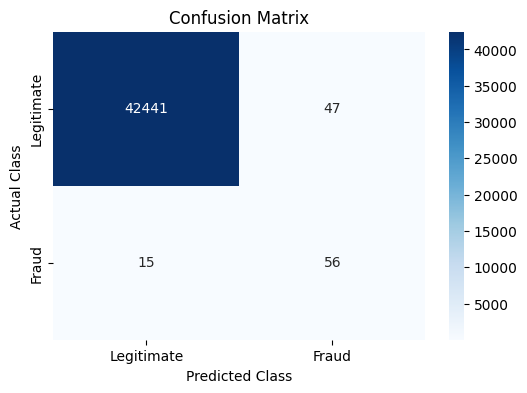

In [94]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

In [95]:
print(
    classification_report(
        y_test,
        best_results["Predictions"],
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42488
       Fraud       0.54      0.79      0.64        71

    accuracy                           1.00     42559
   macro avg       0.77      0.89      0.82     42559
weighted avg       1.00      1.00      1.00     42559



In [97]:
sample_predictions = pd.DataFrame({
    "Actual Class": y_test.iloc[:5].values,
    "Predicted Class": best_results["Predictions"][:5],
    "Fraud Probability": best_results["Probabilities"][:5]
})

sample_predictions

,Actual Class,Predicted Class,Fraud Probability
0,1,0,2.638121e-02
1,0,0,5.319605e-10
2,0,0,5.580979e-22
3,0,0,2.338196e-13
4,0,0,7.861519e-18


TESTING

In [98]:
# Predict fraud probability
y_test_prob = best_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

# Convert probability into 0/1 class
y_test_pred = (y_test_prob >= 0.50).astype(int)

In [102]:
y_test_pred

array([0, 0, 0, ..., 0, 0, 0])

In [103]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_test_pred)

precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9985
Precision: 0.5437
Recall   : 0.7887
F1 Score : 0.6437


# 🏆 Successfully completed